# SLA Breach Prediction — Module 4: Dashboard & NLP Integration Outputs
## AI-Driven Intelligent IT Operations Platform | Innodatatics Capstone — ISB AMPBA 2025W

This notebook is **Module 4 of 4** in the SLA Breach Prediction stream.

### Depends on
Run SLA_01 → SLA_02 → **SLA_03_Model_Improved** → this notebook.

### What changed vs the original SLA_04
- Loads `sla_breach_scores.pkl` from `SLA_03_Model_Improved` (improved scores)
- Validates new `model_version` field in artefacts
- KPI section now shows model version and CatBoost/LightGBM-Optuna info
- AI Insights panel generates richer insight text using the improved breach probability scores
- Model metadata JSON now includes `extra_features_added` from the improved model

### Dual purpose
1. **Dashboard outputs** — CSV + JSON files for the OpsIntel frontend (SLA governance screen)
2. **NLP Ticket Analytics integration** — validates `sla_breach_scores.pkl` format for Ticket_03

### Outputs
| File | Purpose | Consumed by |
|---|---|---|
| `sla_breach_scores.pkl` | Per-ticket breach probability + risk tier | Ticket_03 AHP weights |
| `dashboard_sla_risk_table.csv` | Ranked SLA risk queue | OpsIntel SLA screen |
| `dashboard_sla_compliance_trend.csv` | Monthly compliance % vs target | OpsIntel Overview chart |
| `dashboard_sla_kpis.csv` | KPI card values | OpsIntel KPI row |
| `dashboard_sla_model_summary.csv` | Model leaderboard | OpsIntel Reports screen |
| `sla_insights.json` | AI Insights panel feed | OpsIntel Active AI Insights |
| `sla_compliance_trend.json` | Monthly trend (JSON) | OpsIntel chart feed |
| `sla_model_metadata.json` | Model health info | OpsIntel Reports screen |


In [1]:
# ============================================================
# COLAB + GOOGLE DRIVE SETUP — run this cell first every session
# ============================================================
from google.colab import drive
import os, sys

drive.mount("/content/drive", force_remount=False)

BASE = "/content/drive/MyDrive/Innodatatics_Capstone"
NLP  = f"{BASE}/NLP_Ticket_Analytics"
DATA = f"{BASE}/data"

os.chdir(NLP)
sys.path.insert(0, NLP)

from pathlib import Path

PKL_DIR  = Path(f"{BASE}/ticket_pkl_outputs");      PKL_DIR.mkdir(exist_ok=True)
PLOT_DIR = Path(f"{BASE}/sla_eda_plots");            PLOT_DIR.mkdir(exist_ok=True)
DASH_DIR = Path(f"{BASE}/ticket_dashboard_outputs"); DASH_DIR.mkdir(exist_ok=True)

FILES = {
    2023: Path(f"{DATA}/IT_Ops_Intern_Ready_2023.xlsx"),
    2024: Path(f"{DATA}/IT_Ops_Intern_Ready_2024.xlsx"),
    2025: Path(f"{DATA}/IT_Ops_Intern_Ready_2025.xlsx"),
}

print("✅  Drive mounted")
print(f"   Working dir : {os.getcwd()}")
print(f"   PKL dir     : {PKL_DIR}")
missing = [str(p) for p in FILES.values() if not p.exists()]
if missing:
    print(f"\n⚠️  Missing: {missing}")
else:
    print("   All data files found ✅")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  Drive mounted
   Working dir : /content/drive/MyDrive/Innodatatics_Capstone/NLP_Ticket_Analytics
   PKL dir     : /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs
   All data files found ✅


# 1. Imports & Load All Outputs

In [2]:
# =========================
# 1A. Install (uncomment on first run if packages are not already included)
# =========================
%pip install pandas numpy matplotlib seaborn openpyxl pathlib catboost

import warnings; warnings.filterwarnings("ignore")
import pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from IPython.display import display

DASH_DIR = Path(f"/content/drive/MyDrive/Innodatatics_Capstone/ticket_dashboard_outputs")
DASH_DIR.mkdir(exist_ok=True)

def load_pkl(name):
    path = PKL_DIR / name
    if not path.exists(): print(f"  ⚠️  {name} not found"); return None
    with open(path, "rb") as f: return pickle.load(f)

def save_csv(df, name):
    path = DASH_DIR / name
    df.to_csv(path, index=False)
    print(f"  ✅  {path}  ({len(df):,} rows)")

def save_json(obj, name):
    path = DASH_DIR / name
    with open(path, "w") as f: json.dump(obj, f, indent=2, default=str)
    print(f"  ✅  {path}")

# Load all SLA outputs
sla_base           = load_pkl("sla_base.pkl")
sla_breach_scores  = load_pkl("sla_breach_scores.pkl")
sla_artefacts      = load_pkl("sla_model_artefacts.pkl")
sla_leaderboard    = load_pkl("sla_model_leaderboard.pkl")
sla_eda_summary    = load_pkl("sla_eda_summary.pkl")
sla_featured       = load_pkl("sla_featured.pkl")

# Also load ticket_base from Ticket_01 for cross-stream joining
ticket_base = load_pkl("ticket_base.pkl")

# Try to load improved featured dataset (from SLA_03_Model_Improved)
# Falls back to sla_featured.pkl if v2 not available
sla_featured_v2 = load_pkl("sla_featured_v2.pkl")
if sla_featured_v2 is not None:
    sla_featured = sla_featured_v2
    print("✅  Using sla_featured_v2.pkl (from SLA_03_Model_Improved)")
else:
    print("ℹ️  sla_featured_v2.pkl not found — using sla_featured.pkl (original)")

print("All SLA outputs loaded:")
for name, obj in dict(sla_base=sla_base, sla_breach_scores=sla_breach_scores,
                       sla_artefacts=sla_artefacts, ticket_base=ticket_base).items():
    if obj is not None and hasattr(obj,"shape"):
        print(f"  {name:20s} → {obj.shape}")
    elif obj is not None:
        print(f"  {name:20s} → loaded ✅")
    else:
        print(f"  {name:20s} → ⚠️  not found")

✅  Using sla_featured_v2.pkl (from SLA_03_Model_Improved)
All SLA outputs loaded:
  sla_base             → (22476, 69)
  sla_breach_scores    → (22476, 10)
  sla_artefacts        → loaded ✅
  ticket_base          → (22491, 77)


# 2. Validate NLP Ticket Analytics Integration

In [3]:
# =========================
# 2A. Confirm sla_breach_scores.pkl format matches Ticket_03 expectations
# =========================
# Ticket_03_Engineer_Assignment.ipynb expects:
#   - Column 'ticket_id' for matching against synthetic assignment history
#   - Column 'year_ticket_id' for joining against ticket_base
#   - Column 'sla_breach_prob' (float 0-1)
#   - Column 'sla_risk_tier' (str: 'Low'/'Medium'/'High')
# The engineer assignment AHP weights shift based on sla_risk_tier.

REQUIRED_COLS = ["ticket_id","year_ticket_id","sla_breach_prob","sla_breach_predicted","sla_risk_tier"]

if sla_breach_scores is not None:
    missing_cols = [c for c in REQUIRED_COLS if c not in sla_breach_scores.columns]
    if missing_cols:
        print(f"❌  Missing required columns for Ticket_03: {missing_cols}")
    else:
        print("✅  sla_breach_scores.pkl format validated for Ticket_03 integration")
        print(f"\nShape       : {sla_breach_scores.shape}")
        print(f"Breach prob range: [{sla_breach_scores['sla_breach_prob'].min():.4f}, {sla_breach_scores['sla_breach_prob'].max():.4f}]")
        print(f"\nRisk tier distribution:")
        display(sla_breach_scores["sla_risk_tier"].value_counts())
        print(f"\nSample rows:")
        display(sla_breach_scores[REQUIRED_COLS].head(5))
else:
    print("❌  sla_breach_scores.pkl not found — run SLA_03_Model_Improved.ipynb first")

# Check model version
if sla_breach_scores is not None:
    version = sla_breach_scores.get("model_version", sla_breach_scores.iloc[0].get("model_version","v1")) if isinstance(sla_breach_scores, pd.DataFrame) else "unknown"
    print(f"\nModel version in scores: {version}")
    if hasattr(sla_breach_scores, "__len__") and "model_version" in sla_breach_scores.columns:
        mv = sla_breach_scores["model_version"].iloc[0]
        if mv == "improved_v2":
            print("✅  Scores are from SLA_03_Model_Improved (improved_v2)")
        else:
            print("ℹ️  Scores are from original SLA_03 — consider running SLA_03_Model_Improved for better probabilities")


✅  sla_breach_scores.pkl format validated for Ticket_03 integration

Shape       : (22476, 10)
Breach prob range: [0.4438, 0.5965]

Risk tier distribution:


,count
sla_risk_tier,
Medium,20823
Low,1653



Sample rows:


,ticket_id,year_ticket_id,sla_breach_prob,sla_breach_predicted,sla_risk_tier
0,T0003190,2023_T0003190,0.5402,1,Medium
1,T0003143,2023_T0003143,0.5524,1,Medium
2,T0006262,2023_T0006262,0.5418,1,Medium
3,T0003386,2023_T0003386,0.5132,1,Medium
4,T0001963,2023_T0001963,0.5372,1,Medium



Model version in scores: 0        improved_v2
1        improved_v2
2        improved_v2
3        improved_v2
4        improved_v2
            ...     
22471    improved_v2
22472    improved_v2
22473    improved_v2
22474    improved_v2
22475    improved_v2
Name: model_version, Length: 22476, dtype: object
✅  Scores are from SLA_03_Model_Improved (improved_v2)


In [4]:
# =========================
# 2B. Merge breach scores into ticket_base for full integration view
# =========================
# This merged table is the foundation for all dashboard outputs.
# It combines ticket features + model predictions in one place.

if sla_base is not None and sla_breach_scores is not None:
    merged = sla_base.merge(
        sla_breach_scores[["year_ticket_id","sla_breach_prob",
                            "sla_breach_predicted","sla_risk_tier"]],
        on="year_ticket_id", how="left"
    )
    merged["sla_breach_prob"]       = merged["sla_breach_prob"].fillna(0.0)
    merged["sla_risk_tier"]         = merged["sla_risk_tier"].fillna("Low")
    merged["sla_breach_predicted"]  = merged["sla_breach_predicted"].fillna(0).astype(int)
    merged["sla_num"]               = pd.to_numeric(merged["sla_breach_flag"], errors="coerce").fillna(0)

    print(f"Merged base: {merged.shape}")
    print(f"High risk tickets : {(merged['sla_risk_tier']=='High').sum():,}")
    print(f"Medium risk       : {(merged['sla_risk_tier']=='Medium').sum():,}")
    print(f"Low risk          : {(merged['sla_risk_tier']=='Low').sum():,}")
else:
    print("⚠️  Cannot merge — check sla_base and sla_breach_scores")
    merged = sla_base.copy() if sla_base is not None else pd.DataFrame()


Merged base: (22476, 72)
High risk tickets : 0
Medium risk       : 20,823
Low risk          : 1,653


# 3. Dashboard Output 1 — SLA Risk Ranking Table

In [5]:
# =========================
# 3A. SLA risk table (for Active AI Insights + SLA screen)
# =========================
# Ranked by breach probability descending.
# High-risk tickets appear at the top of the AI Insights panel.
# Matches the wireframe: ticket ID, priority, breach prob, risk tier, action.

SLA_RISK_COLS = [c for c in [
    "year_ticket_id","ticket_id","ticket_priority","ticket_category","issue_type",
    "service_tier","client_id","engineer_id","specialization","experience_years",
    "sla_breach_prob","sla_breach_predicted","sla_risk_tier",
    "sla_breach_flag",                               # actual outcome (for validation)
    "response_time_target_minutes","resolution_time_target_minutes",
    "ticket_channel","device_type","criticality_level","year",
] if c in merged.columns]

sla_risk_table = (merged[SLA_RISK_COLS]
    .sort_values("sla_breach_prob", ascending=False)
    .reset_index(drop=True))

sla_risk_table["rank"] = range(1, len(sla_risk_table) + 1)
sla_risk_table["action"] = sla_risk_table["sla_risk_tier"].map({
    "High":   "Escalate & Reassign Immediately",
    "Medium": "Monitor Closely — Check Engineer Load",
    "Low":    "Standard Assignment"
})

print(f"SLA risk table: {sla_risk_table.shape}")
print("\nTop 10 highest risk tickets:")
display(sla_risk_table[["rank","year_ticket_id","ticket_priority","service_tier",
                          "sla_breach_prob","sla_risk_tier","action"]].head(10))


SLA risk table: (22476, 22)

Top 10 highest risk tickets:


,rank,year_ticket_id,ticket_priority,service_tier,sla_breach_prob,sla_risk_tier,action
0,1,2023_T0005644,P2,Gold,0.5965,Medium,Monitor Closely — Check Engineer Load
1,2,2023_T0000091,P2,Gold,0.5961,Medium,Monitor Closely — Check Engineer Load
2,3,2023_T0000500,P1,Silver,0.5893,Medium,Monitor Closely — Check Engineer Load
3,4,2024_T0001908,P1,Silver,0.5890,Medium,Monitor Closely — Check Engineer Load
4,5,2025_T0006436,P1,Silver,0.5880,Medium,Monitor Closely — Check Engineer Load
5,6,2025_T0006428,P1,Bronze,0.5760,Medium,Monitor Closely — Check Engineer Load
6,7,2023_T0002129,P1,Silver,0.5746,Medium,Monitor Closely — Check Engineer Load
7,8,2024_T0008569,P2,Silver,0.5726,Medium,Monitor Closely — Check Engineer Load
8,9,2023_T0000912,P4,Gold,0.5695,Medium,Monitor Closely — Check Engineer Load
9,10,2024_T0003212,P4,Bronze,0.5692,Medium,Monitor Closely — Check Engineer Load


# 4. Dashboard Output 2 — KPI Cards

In [6]:
# =========================
# 4A. Compute SLA KPI values
# =========================
# These populate the KPI row in the OpsIntel Overview screen.
# Mirrors the wireframe: Total Tickets, SLA Compliance %, Breach Count, High Risk Count.

total_tickets        = len(merged)
breach_count         = int(merged["sla_num"].sum())
compliance_rate      = round(1 - merged["sla_num"].mean(), 4)
avg_breach_prob      = round(float(merged["sla_breach_prob"].mean()), 4)
high_risk_count      = int((merged["sla_risk_tier"] == "High").sum())
medium_risk_count    = int((merged["sla_risk_tier"] == "Medium").sum())
predicted_breaches   = int(merged["sla_breach_predicted"].sum())

# Year-over-year compliance change
if "year" in merged.columns:
    yoy = merged.groupby("year")["sla_num"].agg(["sum","count","mean"])
    yoy.columns = ["breaches","tickets","breach_rate"]
    yoy["compliance_rate"] = 1 - yoy["breach_rate"]
    print("Year-over-year SLA compliance:")
    display(yoy.round(4))

sla_kpis = {
    "total_tickets":           f"{total_tickets:,}",
    "sla_breach_count":        f"{breach_count:,}",
    "sla_compliance_rate":     f"{compliance_rate*100:.1f}%",
    "predicted_breaches":      f"{predicted_breaches:,}",
    "high_risk_count":         f"{high_risk_count:,}",
    "medium_risk_count":       f"{medium_risk_count:,}",
    "avg_predicted_breach_prob":f"{avg_breach_prob:.4f}",
    "model_name":              sla_artefacts["best_model_name"] if sla_artefacts else "—",
    "model_version":           sla_artefacts.get("model_version","v1") if sla_artefacts else "—",
    "model_roc_auc":           str(sla_leaderboard.iloc[0]["ROC-AUC"]) if sla_leaderboard is not None else "—",
    "optimal_threshold":       str(round(sla_artefacts["optimal_threshold"], 4)) if sla_artefacts else "—",
    "extra_features_count":    str(len(sla_artefacts.get("extra_features_added",[]))) if sla_artefacts else "0",
}

print("\nSLA KPI values:")
for k, v in sla_kpis.items():
    print(f"  {k:35s} : {v}")


Year-over-year SLA compliance:


,breaches,tickets,breach_rate,compliance_rate
year,,,,
2023,2784.0,6962,0.3999,0.6001
2024,3128.0,8040,0.3891,0.6109
2025,2994.0,7474,0.4006,0.5994



SLA KPI values:
  total_tickets                       : 22,476
  sla_breach_count                    : 8,906
  sla_compliance_rate                 : 60.4%
  predicted_breaches                  : 20,823
  high_risk_count                     : 0
  medium_risk_count                   : 20,823
  avg_predicted_breach_prob           : 0.4997
  model_name                          : CatBoost
  model_version                       : improved_v2
  model_roc_auc                       : 0.5058
  optimal_threshold                   : 0.4922
  extra_features_count                : 19


# 5. Dashboard Output 3 — Compliance Trend

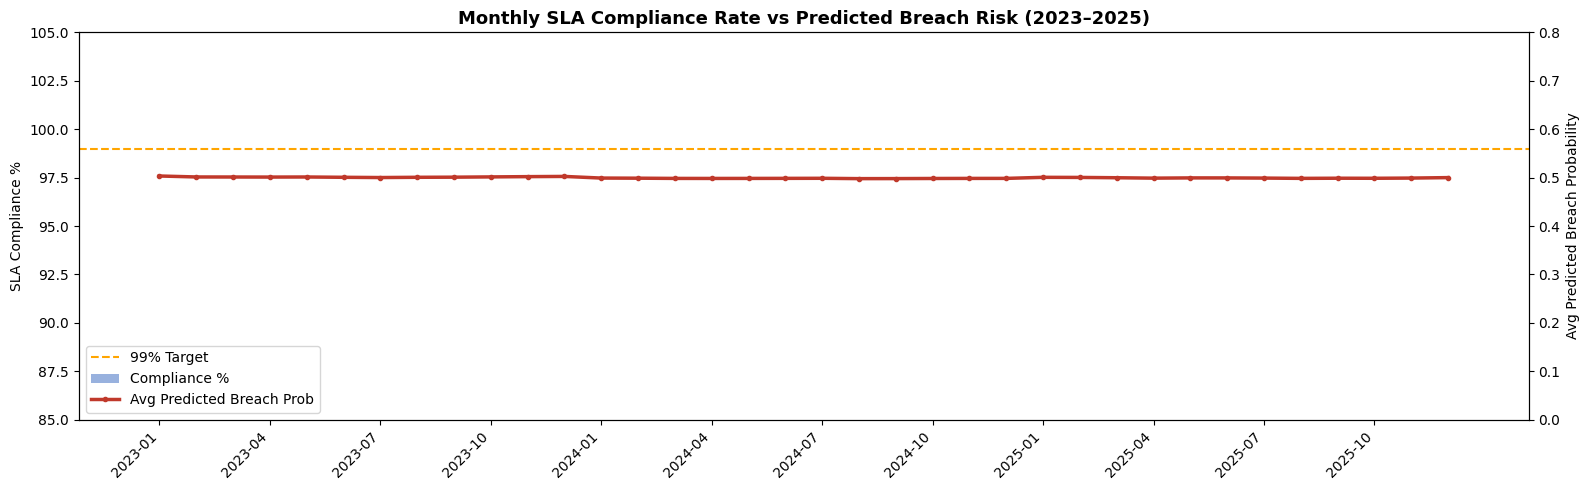

In [7]:
# =========================
# 5A. Monthly SLA compliance trend (for chart in Overview screen)
# =========================
import calendar

ts = merged.dropna(subset=["ticket_created_timestamp"]).copy()
ts["ym"] = ts["ticket_created_timestamp"].dt.to_period("M")

monthly_trend = (ts.groupby("ym")
    .agg(
        tickets=("sla_num","count"),
        breaches=("sla_num","sum"),
        compliance_rate=("sla_num", lambda s: round(1 - s.mean(), 4)),
        avg_breach_prob=("sla_breach_prob","mean"),
        high_risk_tickets=("sla_risk_tier", lambda s: (s=="High").sum()),
    )
    .reset_index())
monthly_trend["ym"]           = monthly_trend["ym"].astype(str)
monthly_trend["sla_target"]   = 0.99   # 99% SLA target
monthly_trend["compliance_pct"] = monthly_trend["compliance_rate"] * 100

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.bar(range(len(monthly_trend)), monthly_trend["compliance_pct"],
        alpha=0.55, color="#4472C4", label="Compliance %")
ax2.plot(range(len(monthly_trend)), monthly_trend["avg_breach_prob"],
         color="#C0392B", linewidth=2.5, marker="o", markersize=3,
         label="Avg Predicted Breach Prob")
ax1.axhline(99, color="orange", linestyle="--", linewidth=1.5, label="99% Target")
ax1.set_xticks(range(0, len(monthly_trend), 3))
ax1.set_xticklabels(monthly_trend["ym"].iloc[::3], rotation=45, ha="right")
ax1.set_ylabel("SLA Compliance %"); ax2.set_ylabel("Avg Predicted Breach Probability")
ax1.set_ylim(85, 105); ax2.set_ylim(0, 0.8)
ax1.set_title("Monthly SLA Compliance Rate vs Predicted Breach Risk (2023–2025)",
              fontweight="bold", fontsize=13)
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc="lower left")
plt.tight_layout()
plt.savefig(Path("/content/drive/MyDrive/Innodatatics_Capstone/sla_eda_plots")/"dashboard_compliance_trend.png",
            dpi=150, bbox_inches="tight")
plt.show()


# 6. Dashboard Output 4 — AI Insights Panel

In [8]:
# =========================
# 6A. AI Insights entries (for Active AI Insights panel)
# =========================
# Mirrors the wireframe's "Active AI Insights" queue:
# ranked by urgency, with a descriptive insight and suggested action.

ai_insights = []

# High-risk SLA tickets
high_risk = sla_risk_table[sla_risk_table["sla_risk_tier"] == "High"].head(10)
for _, row in high_risk.iterrows():
    ai_insights.append({
        "insight_type":      "Predictive SLA Breach",
        "severity":          "Critical",
        "year_ticket_id":    str(row.get("year_ticket_id","")),
        "ticket_priority":   str(row.get("ticket_priority","")),
        "ticket_category":   str(row.get("ticket_category","")),
        "service_tier":      str(row.get("service_tier","")),
        "client_id":         str(row.get("client_id","")),
        "breach_probability":round(float(row["sla_breach_prob"]), 4),
        "risk_tier":         "High",
        "insight_text":      (f"Ticket {row.get('year_ticket_id','')} — {row.get('ticket_priority','')} "
                              f"{row.get('ticket_category','')} for {row.get('service_tier','')} client. "
                              f"Predicted breach probability: {row['sla_breach_prob']:.1%}. "
                              f"Assigned engineer's SLA track record is the primary risk driver."),
        "action":            "Escalate & Reassign to Senior Engineer",
    })

# Medium-risk tickets with high-priority flag
med_p1 = sla_risk_table[
    (sla_risk_table["sla_risk_tier"] == "Medium") &
    (sla_risk_table["ticket_priority"] == "P1")
].head(5)
for _, row in med_p1.iterrows():
    ai_insights.append({
        "insight_type":      "Elevated SLA Risk",
        "severity":          "Warning",
        "year_ticket_id":    str(row.get("year_ticket_id","")),
        "ticket_priority":   "P1",
        "breach_probability":round(float(row["sla_breach_prob"]), 4),
        "risk_tier":         "Medium",
        "insight_text":      (f"P1 ticket {row.get('year_ticket_id','')} at medium breach risk "
                              f"({row['sla_breach_prob']:.1%}). Monitor response time closely."),
        "action":            "Monitor — Check Engineer Workload",
    })

# Compliance trend alert
latest_month = monthly_trend.iloc[-1]
if latest_month["compliance_rate"] < 0.97:
    ai_insights.append({
        "insight_type":  "Compliance Alert",
        "severity":      "Warning",
        "insight_text":  (f"SLA compliance for {latest_month['ym']} is "
                          f"{latest_month['compliance_pct']:.1f}% — below 99% target. "
                          f"{int(latest_month['high_risk_tickets'])} tickets at high breach risk."),
        "action":        "Review Engineer Allocation",
    })

print(f"AI Insights entries: {len(ai_insights)}")
display(pd.DataFrame(ai_insights)[["insight_type","severity","breach_probability","action"]].head(10))


AI Insights entries: 6


,insight_type,severity,breach_probability,action
0,Elevated SLA Risk,Warning,0.5893,Monitor — Check Engineer Workload
1,Elevated SLA Risk,Warning,0.5890,Monitor — Check Engineer Workload
2,Elevated SLA Risk,Warning,0.5880,Monitor — Check Engineer Workload
3,Elevated SLA Risk,Warning,0.5760,Monitor — Check Engineer Workload
4,Elevated SLA Risk,Warning,0.5746,Monitor — Check Engineer Workload
5,Compliance Alert,Warning,NaN,Review Engineer Allocation


# 7. Save All Outputs

In [9]:
# =========================
# 7A. Save all dashboard CSV files
# =========================
save_csv(sla_risk_table,    "dashboard_sla_risk_table.csv")
save_csv(monthly_trend,     "dashboard_sla_compliance_trend.csv")
save_csv(pd.DataFrame([sla_kpis]).T.reset_index().rename(columns={"index":"metric",0:"value"}),
         "dashboard_sla_kpis.csv")

if sla_leaderboard is not None:
    save_csv(sla_leaderboard, "dashboard_sla_model_summary.csv")

# Feature importance table
if sla_artefacts is not None and "perm_importance" in sla_artefacts:
    save_csv(sla_artefacts["perm_importance"], "dashboard_sla_feature_importance.csv")

# =========================
# 7B. Save JSON files (for dashboard plugin)
# =========================
# sla_compliance_trend.json — consumed by NLP ticket engine JSON feed (tickets_enriched)
sla_trend_json = monthly_trend[["ym","tickets","compliance_pct","avg_breach_prob","sla_target"]].to_dict(orient="records")
save_json(sla_trend_json,  "sla_compliance_trend.json")
save_json(ai_insights,     "sla_insights.json")

# SLA model metadata for the dashboard's model health panel
model_meta = {
    "model_name":         sla_artefacts["best_model_name"] if sla_artefacts else "—",
    "roc_auc":            str(sla_leaderboard.iloc[0]["ROC-AUC"]) if sla_leaderboard is not None else "—",
    "pr_auc":             str(sla_leaderboard.iloc[0]["PR-AUC"]) if sla_leaderboard is not None else "—",
    "optimal_threshold":  round(sla_artefacts["optimal_threshold"], 4) if sla_artefacts else 0.5,
    "high_tier_threshold":round(sla_artefacts["high_tier_threshold"], 4) if sla_artefacts else 0.7,
    "med_tier_threshold": round(sla_artefacts["med_tier_threshold"], 4) if sla_artefacts else 0.4,
    "total_tickets_scored": len(sla_breach_scores) if sla_breach_scores is not None else 0,
    "high_risk_count":    high_risk_count,
    "medium_risk_count":  medium_risk_count,
    "training_period":    "2023–2024",
    "test_period":        "2025",
    "model_version":      sla_artefacts.get("model_version","v1") if sla_artefacts else "v1",
    "extra_features_added": sla_artefacts.get("extra_features_added",[]) if sla_artefacts else [],
    "feature_count":      len(sla_artefacts.get("final_cats",[])) + len(sla_artefacts.get("final_nums",[])) if sla_artefacts else 0,
}
save_json(model_meta, "sla_model_metadata.json")

print(f"\n✅  Module 4 complete. All outputs saved to: {DASH_DIR}")
print("\nFiles generated:")
for f in sorted(DASH_DIR.iterdir()):
    if "sla" in f.name.lower():
        print(f"  {f.name}")

print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("  NLP TICKET ANALYTICS INTEGRATION STATUS")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
if (PKL_DIR/"sla_breach_scores.pkl").exists():
    print("  ✅  sla_breach_scores.pkl is present in ticket_pkl_outputs/")
    print("  ✅  Ticket_03_Engineer_Assignment.ipynb will use breach-aware AHP weights")
    print("  ✅  High-risk tickets (prob >= {:.3f}) → exp≥5yr + SLA success rate weight 0.451".format(
          sla_artefacts["high_tier_threshold"] if sla_artefacts else 0.7))
    print("  ✅  Medium-risk (prob >= {:.3f}) → exp≥3yr + balanced weights".format(
          sla_artefacts["med_tier_threshold"] if sla_artefacts else 0.4))
else:
    print("  ❌  sla_breach_scores.pkl NOT found — Ticket_03 will use default Low risk for all tickets")


  ✅  /content/drive/MyDrive/Innodatatics_Capstone/ticket_dashboard_outputs/dashboard_sla_risk_table.csv  (22,476 rows)
  ✅  /content/drive/MyDrive/Innodatatics_Capstone/ticket_dashboard_outputs/dashboard_sla_compliance_trend.csv  (36 rows)
  ✅  /content/drive/MyDrive/Innodatatics_Capstone/ticket_dashboard_outputs/dashboard_sla_kpis.csv  (12 rows)
  ✅  /content/drive/MyDrive/Innodatatics_Capstone/ticket_dashboard_outputs/dashboard_sla_model_summary.csv  (6 rows)
  ✅  /content/drive/MyDrive/Innodatatics_Capstone/ticket_dashboard_outputs/sla_compliance_trend.json
  ✅  /content/drive/MyDrive/Innodatatics_Capstone/ticket_dashboard_outputs/sla_insights.json
  ✅  /content/drive/MyDrive/Innodatatics_Capstone/ticket_dashboard_outputs/sla_model_metadata.json

✅  Module 4 complete. All outputs saved to: /content/drive/MyDrive/Innodatatics_Capstone/ticket_dashboard_outputs

Files generated:
  dashboard_sla_compliance_trend.csv
  dashboard_sla_kpis.csv
  dashboard_sla_model_summary.csv
  dashboard_